# Notebook 3 — Network Analysis
## COSC 2671 Social Media and Network Analysis — Assignment 2
### "Who Drives Open-Source AI? Network Centrality and Discourse Analysis on GitHub ML Repositories"

**Goal:** Build directed weighted interaction networks from cleaned issue/comment data, compute centrality measures, detect communities via Louvain, perform k-core decomposition, and produce all outputs required for Notebook 4 and the final report.

**Inputs:** `data/processed/{safe_name}_clean.csv`  
**Outputs:** centrality tables, GEXF graphs, pyvis HTML, bar charts, cross-repo comparison table

## Cell 2 — Set Working Directory

In [1]:
from pathlib import Path
import os

PROJECT_ROOT = next(
    path.parent.parent
    for path in Path.home().rglob("data/raw")
    if (
        (path.parent / "processed").is_dir()
        and (path.parent.parent / "notebooks").is_dir()
        and (path.parent.parent / "outputs").is_dir()
    )
)

os.chdir(PROJECT_ROOT)

print(f"Working directory: {os.getcwd()}")
print(f"data/raw exists: {os.path.exists('data/raw')}")
print(f"data/processed exists: {os.path.exists('data/processed')}")
print(f"outputs/tables exists: {os.path.exists('outputs/tables')}")
print(f"outputs/figures exists: {os.path.exists('outputs/figures')}")

Working directory: /Users/rob/Desktop/2026/social/SMNA2026-A2-github-networks
data/raw exists: True
data/processed exists: True
outputs/tables exists: True
outputs/figures exists: True


## Cell 3 — Imports, Constants, SAFE_NAMES

In [2]:
import json
import warnings
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain   # python-louvain
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pyvis.network import Network
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ── Repositories ────────────────────────────────────────────────────
REPOS = [
    "scikit-learn/scikit-learn",
    "huggingface/transformers",
    "pytorch/pytorch",
    "keras-team/keras",
    "langchain-ai/langchain",
]

SAFE_NAMES = {
    "scikit-learn/scikit-learn": "scikit-learn_scikit-learn",
    "huggingface/transformers":  "huggingface_transformers",
    "pytorch/pytorch":           "pytorch_pytorch",
    "keras-team/keras":          "keras-team_keras",
    "langchain-ai/langchain":    "langchain-ai_langchain",
}

# ── Paths ────────────────────────────────────────────────────────────
PROCESSED_DIR  = "data/processed"
TABLES_DIR     = "outputs/tables"
FIGURES_DIR    = "outputs/figures"
GEXF_DIR       = "data/processed"        # GEXF alongside CSVs

print("Imports OK.")
print(f"Repos: {len(REPOS)}")

Imports OK.
Repos: 5


## Cell 4 — Build and Filter Network

In [3]:
def build_network(df: pd.DataFrame) -> nx.DiGraph:
    G = nx.DiGraph()

    comments = df[df["type"] == "comment"].dropna(subset=["author", "parent_author"])
    comments = comments[comments["author"] != comments["parent_author"]]  # no self-loops
    edge_counts = comments.groupby(["author", "parent_author"]).size().reset_index(name="weight")

    for _, row in edge_counts.iterrows():
        G.add_edge(row["author"], row["parent_author"], weight=int(row["weight"]))

    return G


def filter_network(G: nx.DiGraph, min_degree: int = 2) -> nx.DiGraph:
    """
    1. Remove nodes with total degree < min_degree.
    2. Keep only the largest weakly connected component.
    """
    # Degree filter (undirected degree = in + out)
    to_remove = [n for n in G.nodes() if G.degree(n) < min_degree]
    G.remove_nodes_from(to_remove)

    # Largest weakly connected component
    if G.number_of_nodes() == 0:
        return G
    wcc = max(nx.weakly_connected_components(G), key=len)
    G = G.subgraph(wcc).copy()

    return G


print("build_network() and filter_network() defined.")

build_network() and filter_network() defined.


## Cell 5 — Compute Centrality

In [4]:
def compute_centrality(G: nx.DiGraph) -> pd.DataFrame:
    """
    Compute PageRank, betweenness centrality, normalised in-degree,
    and a composite score. Returns a DataFrame sorted by composite score.

    Composite = 0.4 × PageRank + 0.3 × Betweenness + 0.3 × Norm_InDegree
    """
    n = G.number_of_nodes()
    if n == 0:
        return pd.DataFrame()

    # ── Centrality measures ─────────────────────────────────────────
    pagerank    = nx.pagerank(G, alpha=0.85, weight="weight")
    betweenness = nx.betweenness_centrality(G, normalized=True, weight="weight")

    max_in = max(dict(G.in_degree()).values()) if n > 1 else 1
    norm_indegree = {node: G.in_degree(node) / max_in for node in G.nodes()}

    # ── Composite score ─────────────────────────────────────────────
    composite = {
        node: (0.4 * pagerank[node]
               + 0.3 * betweenness[node]
               + 0.3 * norm_indegree[node])
        for node in G.nodes()
    }

    df = pd.DataFrame({
        "user":           list(G.nodes()),
        "pagerank":       [pagerank[n]      for n in G.nodes()],
        "betweenness":    [betweenness[n]   for n in G.nodes()],
        "norm_indegree":  [norm_indegree[n] for n in G.nodes()],
        "in_degree":      [G.in_degree(n)   for n in G.nodes()],
        "out_degree":     [G.out_degree(n)  for n in G.nodes()],
        "composite":      [composite[n]     for n in G.nodes()],
    }).sort_values("composite", ascending=False).reset_index(drop=True)

    df.index += 1   # 1-based rank
    df.insert(0, "rank", df.index)

    return df


print("compute_centrality() defined.")

compute_centrality() defined.


## Cell 6 — Community Detection (Louvain)

In [5]:
def detect_communities(G: nx.DiGraph) -> tuple[dict, float]:
    """
    Run Louvain community detection on the undirected version of G.
    Returns (partition dict, modularity score).
    """
    G_und = G.to_undirected()
    partition  = community_louvain.best_partition(G_und, weight="weight", random_state=42)
    modularity = community_louvain.modularity(partition, G_und, weight="weight")
    return partition, modularity


def community_summary(partition: dict) -> pd.DataFrame:
    """Return a DataFrame counting nodes per community, sorted descending."""
    counts = pd.Series(partition).value_counts().reset_index()
    counts.columns = ["community_id", "node_count"]
    counts = counts.sort_values("node_count", ascending=False).reset_index(drop=True)
    return counts


print("detect_communities() and community_summary() defined.")

detect_communities() and community_summary() defined.


## Cell 7 — k-Core Decomposition

In [6]:
def kcore_analysis(G: nx.DiGraph, centrality_df: pd.DataFrame, top_n: int = 30) -> dict:
    """
    Compute k-core decomposition on undirected version.
    Report max k-core and overlap with top-N PageRank nodes.
    """
    G_und  = G.to_undirected()
    cores  = nx.core_number(G_und)
    max_k  = max(cores.values()) if cores else 0

    max_core_nodes = {n for n, k in cores.items() if k == max_k}
    top_pr_nodes   = set(centrality_df.head(top_n)["user"].tolist())
    overlap        = max_core_nodes & top_pr_nodes

    # Attach core number to centrality_df
    centrality_df = centrality_df.copy()
    centrality_df["core_number"] = centrality_df["user"].map(cores).fillna(0).astype(int)

    result = {
        "max_k":             max_k,
        "max_core_nodes":    max_core_nodes,
        "max_core_size":     len(max_core_nodes),
        "top_pr_overlap":    len(overlap),
        "overlap_pct":       round(len(overlap) / top_n * 100, 1),
        "centrality_df":     centrality_df,
        "core_number_map":   cores,
    }
    print(f"  Max k-core: {max_k}  |  Core size: {len(max_core_nodes)}  "
          f"|  Overlap with top-{top_n} PageRank: {len(overlap)} ({result['overlap_pct']}%)")
    return result


print("kcore_analysis() defined.")

kcore_analysis() defined.


## Cell 8 — pyvis Visualisation

In [7]:
def visualise_network(G: nx.DiGraph, partition: dict, centrality_df: pd.DataFrame,
                      repo: str, safe: str, top_n: int = 100) -> str:
    """
    Build a pyvis interactive HTML showing the top_n nodes by composite score.
    Nodes coloured by Louvain community, sized by PageRank.
    """
    os.makedirs(f"{FIGURES_DIR}/networks", exist_ok=True)
    out_path = f"{FIGURES_DIR}/networks/{safe}_network.html"

    # Restrict to top_n nodes for rendering performance
    top_nodes  = set(centrality_df.head(top_n)["user"].tolist())
    sub        = G.subgraph(top_nodes).copy()

    # Colour palette for communities
    community_ids = sorted(set(partition.get(n, 0) for n in sub.nodes()))
    palette = plt.colormaps["tab20"].resampled(max(len(community_ids), 1))
    color_map     = {cid: "#{:02x}{:02x}{:02x}".format(
                        int(palette(i)[0]*255),
                        int(palette(i)[1]*255),
                        int(palette(i)[2]*255))
                     for i, cid in enumerate(community_ids)}

    pr_values = dict(zip(centrality_df["user"], centrality_df["pagerank"]))
    pr_max    = max(pr_values.values()) if pr_values else 1

    net = Network(height="750px", width="100%", directed=True,
                  notebook=False, bgcolor="#1a1a2e", font_color="white")
    net.barnes_hut(gravity=-8000, central_gravity=0.3, spring_length=120)

    for node in sub.nodes():
        pr_norm   = pr_values.get(node, 0) / pr_max
        size      = 8 + pr_norm * 35
        cid       = partition.get(node, 0)
        color     = color_map.get(cid, "#888888")
        net.add_node(node, label=node, size=size, color=color,
                     title=f"{node}<br>PageRank: {pr_values.get(node,0):.4f}<br>Community: {cid}")

    for src, dst, data in sub.edges(data=True):
        w = data.get("weight", 1)
        net.add_edge(src, dst, value=w, title=f"weight: {w}")

    net.save_graph(out_path)
    print(f"  Saved pyvis HTML → {out_path}")
    return out_path


print("visualise_network() defined.")

visualise_network() defined.


## Cell 9 — Bar Chart: Top-20 Contributors

In [8]:
def plot_top_20(centrality_df: pd.DataFrame, repo: str, safe: str) -> None:
    """Bar chart of top-20 contributors by composite centrality score."""
    top20 = centrality_df.head(20).copy()

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(top20["user"][::-1], top20["composite"][::-1],
                   color=sns.color_palette("viridis", 20))

    ax.set_xlabel("Composite Centrality Score\n(0.4 × PageRank + 0.3 × Betweenness + 0.3 × Norm In-Degree)",
                  fontsize=10)
    ax.set_title(f"Top-20 Central Contributors\n{repo}", fontsize=12, fontweight="bold")
    ax.tick_params(axis="y", labelsize=8)

    # Annotate bar values
    for bar, val in zip(bars, top20["composite"][::-1]):
        ax.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", ha="left", fontsize=7)

    plt.tight_layout()
    out_path = f"{FIGURES_DIR}/{safe}_top20_centrality.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved bar chart → {out_path}")


print("plot_top_20() defined.")

plot_top_20() defined.


## Cell 10 — Main Analysis Loop


  scikit-learn/scikit-learn
  Loaded 11,469 rows
  Nodes: 769  |  Edges: 2,239  |  Density: 0.00379
  ✓ SC1 passed
  Computing centrality...
  ✓ SC2: top-20 identified — #1: glemaitre (composite=0.3265)
  Detecting communities...
  Communities: 12  |  Modularity: 0.3788
  ✓ SC3 passed (modularity=0.3788)
  Running k-core analysis...
  Max k-core: 10  |  Core size: 24  |  Overlap with top-30 PageRank: 21 (70.0%)
  Saved top-20 centrality → outputs/tables/scikit-learn_scikit-learn_centrality.csv
  Saved GEXF → data/processed/scikit-learn_scikit-learn_network.gexf
  Building pyvis visualisation...
  Saved pyvis HTML → outputs/figures/networks/scikit-learn_scikit-learn_network.html


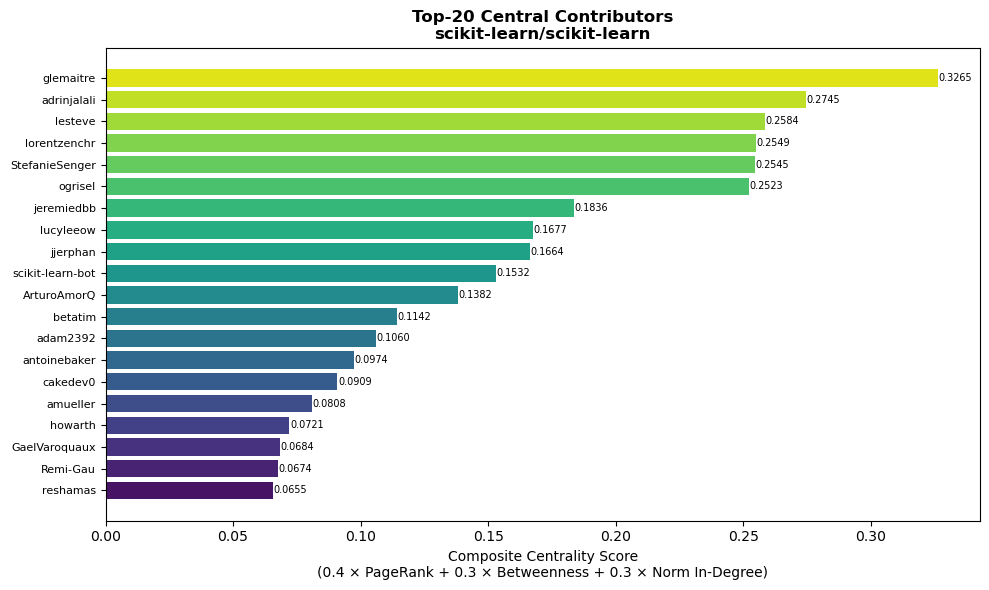

  Saved bar chart → outputs/figures/scikit-learn_scikit-learn_top20_centrality.png

  ── scikit-learn/scikit-learn complete ──

  huggingface/transformers
  Loaded 9,073 rows
  Nodes: 948  |  Edges: 1,975  |  Density: 0.00220
  ✓ SC1 passed
  Computing centrality...
  ✓ SC2: top-20 identified — #1: qgallouedec (composite=0.3057)
  Detecting communities...
  Communities: 21  |  Modularity: 0.5408
  ✓ SC3 passed (modularity=0.5408)
  Running k-core analysis...
  Max k-core: 5  |  Core size: 22  |  Overlap with top-30 PageRank: 15 (50.0%)
  Saved top-20 centrality → outputs/tables/huggingface_transformers_centrality.csv
  Saved GEXF → data/processed/huggingface_transformers_network.gexf
  Building pyvis visualisation...
  Saved pyvis HTML → outputs/figures/networks/huggingface_transformers_network.html


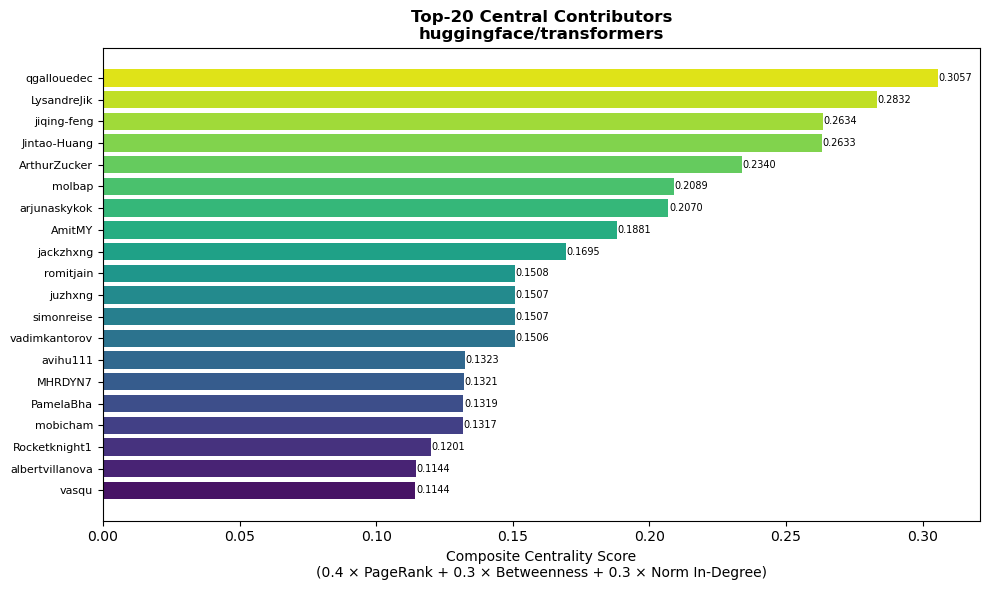

  Saved bar chart → outputs/figures/huggingface_transformers_top20_centrality.png

  ── huggingface/transformers complete ──

  pytorch/pytorch
  Loaded 5,028 rows
  Nodes: 409  |  Edges: 1,012  |  Density: 0.00606
  ✓ SC1 passed
  Computing centrality...
  ✓ SC2: top-20 identified — #1: atalman (composite=0.3416)
  Detecting communities...
  Communities: 14  |  Modularity: 0.5640
  ✓ SC3 passed (modularity=0.5640)
  Running k-core analysis...
  Max k-core: 5  |  Core size: 52  |  Overlap with top-30 PageRank: 24 (80.0%)
  Saved top-20 centrality → outputs/tables/pytorch_pytorch_centrality.csv
  Saved GEXF → data/processed/pytorch_pytorch_network.gexf
  Building pyvis visualisation...
  Saved pyvis HTML → outputs/figures/networks/pytorch_pytorch_network.html


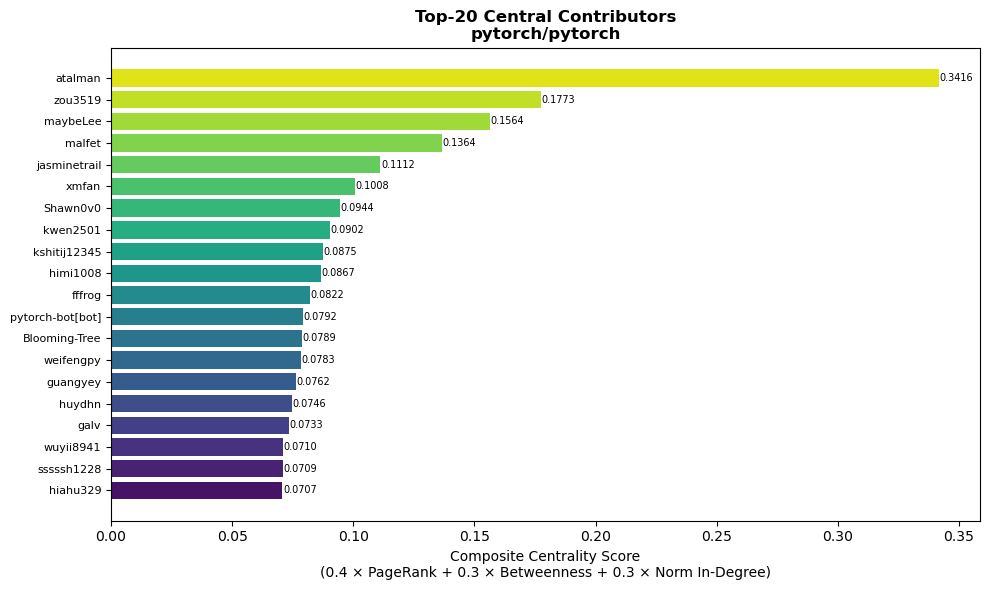

  Saved bar chart → outputs/figures/pytorch_pytorch_top20_centrality.png

  ── pytorch/pytorch complete ──

  keras-team/keras
  Loaded 9,324 rows
  Nodes: 758  |  Edges: 2,167  |  Density: 0.00378
  ✓ SC1 passed
  Computing centrality...
  ✓ SC2: top-20 identified — #1: innat (composite=0.3147)
  Detecting communities...
  Communities: 10  |  Modularity: 0.4663
  ✓ SC3 passed (modularity=0.4663)
  Running k-core analysis...
  Max k-core: 8  |  Core size: 24  |  Overlap with top-30 PageRank: 14 (46.7%)
  Saved top-20 centrality → outputs/tables/keras-team_keras_centrality.csv
  Saved GEXF → data/processed/keras-team_keras_network.gexf
  Building pyvis visualisation...
  Saved pyvis HTML → outputs/figures/networks/keras-team_keras_network.html


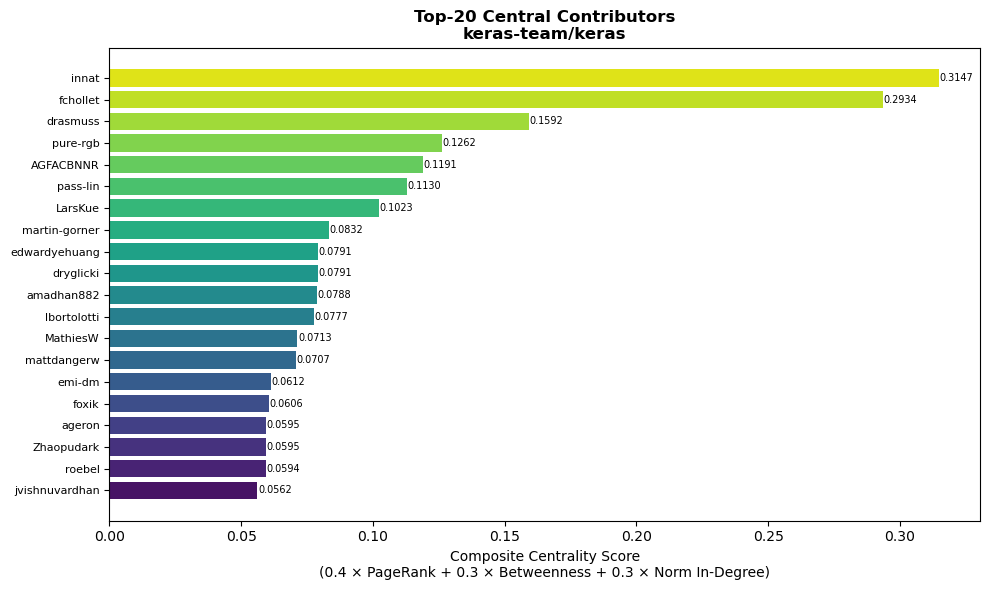

  Saved bar chart → outputs/figures/keras-team_keras_top20_centrality.png

  ── keras-team/keras complete ──

  langchain-ai/langchain
  Loaded 7,656 rows
  Nodes: 839  |  Edges: 1,449  |  Density: 0.00206
  ✓ SC1 passed
  Computing centrality...
  ✓ SC2: top-20 identified — #1: mdrxy (composite=0.3136)
  Detecting communities...
  Communities: 20  |  Modularity: 0.6545
  ✓ SC3 passed (modularity=0.6545)
  Running k-core analysis...
  Max k-core: 4  |  Core size: 23  |  Overlap with top-30 PageRank: 14 (46.7%)
  Saved top-20 centrality → outputs/tables/langchain-ai_langchain_centrality.csv
  Saved GEXF → data/processed/langchain-ai_langchain_network.gexf
  Building pyvis visualisation...
  Saved pyvis HTML → outputs/figures/networks/langchain-ai_langchain_network.html


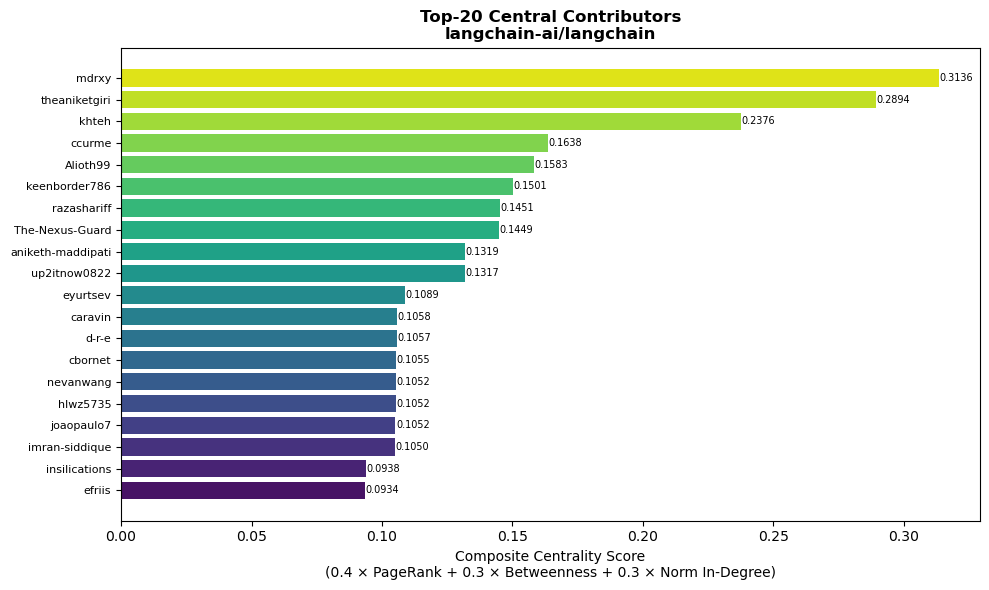

  Saved bar chart → outputs/figures/langchain-ai_langchain_top20_centrality.png

  ── langchain-ai/langchain complete ──


✅ All repos processed.


In [9]:
# Storage for cross-repo comparison (Cell 11)
summary_rows = []
# Storage for Notebook 4 (Cell 13)
all_centrality = {}

for repo in REPOS:
    safe = SAFE_NAMES[repo]
    print(f"\n{'='*60}")
    print(f"  {repo}")
    print(f"{'='*60}")

    # ── Load cleaned CSV ─────────────────────────────────────────
    csv_path = f"{PROCESSED_DIR}/{safe}_clean.csv"
    df = pd.read_csv(csv_path, low_memory=False)
    print(f"  Loaded {len(df):,} rows")

    # ── Build + filter network ───────────────────────────────────
    G_raw = build_network(df)
    G     = filter_network(G_raw, min_degree=2)
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    density = nx.density(G)
    print(f"  Nodes: {n_nodes:,}  |  Edges: {n_edges:,}  |  Density: {density:.5f}")

    # SC1 check
    if n_nodes < 100 or n_edges < 200:
        print(f"  ⚠ SC1 WARNING: below threshold (nodes<100 or edges<200)")
    else:
        print(f"  ✓ SC1 passed")

    # ── Centrality ───────────────────────────────────────────────
    print("  Computing centrality...")
    cent_df = compute_centrality(G)
    print(f"  ✓ SC2: top-20 identified — #{1}: {cent_df.iloc[0]['user']} "
          f"(composite={cent_df.iloc[0]['composite']:.4f})")

    # ── Community detection ──────────────────────────────────────
    print("  Detecting communities...")
    partition, modularity = detect_communities(G)
    n_communities = len(set(partition.values()))
    print(f"  Communities: {n_communities}  |  Modularity: {modularity:.4f}")
    if modularity > 0.3:
        print(f"  ✓ SC3 passed (modularity={modularity:.4f})")
    else:
        print(f"  ⚠ SC3 WARNING: modularity={modularity:.4f} < 0.3")

    # ── k-Core ──────────────────────────────────────────────────
    print("  Running k-core analysis...")
    kcore = kcore_analysis(G, cent_df, top_n=30)
    cent_df = kcore["centrality_df"]   # now includes core_number column

    # ── Save centrality table (top-20) ──────────────────────────
    top20_path = f"{TABLES_DIR}/{safe}_centrality.csv"
    cent_df.head(20).to_csv(top20_path, index=False)
    print(f"  Saved top-20 centrality → {top20_path}")

    # ── Save full centrality for Notebook 4 ─────────────────────
    all_centrality[repo] = cent_df   # full, not just top-20

    # ── Save network as GEXF ─────────────────────────────────────
    # Attach community and centrality attributes to nodes
    for node in G.nodes():
        G.nodes[node]["community"]    = partition.get(node, -1)
        G.nodes[node]["core_number"]  = kcore["core_number_map"].get(node, 0)
        row = cent_df[cent_df["user"] == node]
        if not row.empty:
            G.nodes[node]["pagerank"]    = float(row["pagerank"].iloc[0])
            G.nodes[node]["betweenness"] = float(row["betweenness"].iloc[0])
            G.nodes[node]["composite"]   = float(row["composite"].iloc[0])

    gexf_path = f"{GEXF_DIR}/{safe}_network.gexf"
    nx.write_gexf(G, gexf_path)
    print(f"  Saved GEXF → {gexf_path}")

    # ── Visualise ────────────────────────────────────────────────
    print("  Building pyvis visualisation...")
    visualise_network(G, partition, cent_df, repo, safe, top_n=100)

    # ── Bar chart ────────────────────────────────────────────────
    plot_top_20(cent_df, repo, safe)

    # ── Collect summary row ──────────────────────────────────────
    summary_rows.append({
        "repo":         repo,
        "nodes":        n_nodes,
        "edges":        n_edges,
        "density":      round(density, 6),
        "communities":  n_communities,
        "modularity":   round(modularity, 4),
        "max_k_core":   kcore["max_k"],
        "top_pr_node":  cent_df.iloc[0]["user"],
        "sc1_pass":     n_nodes >= 100 and n_edges >= 200,
        "sc3_pass":     modularity > 0.3,
    })

    print(f"\n  ── {repo} complete ──")

print("\n\n✅ All repos processed.")

## Cell 11 — Cross-Repo Comparison Table


── Cross-Repo Network Summary ──

                     repo  nodes  edges  density  communities  modularity  max_k_core top_pr_node
scikit-learn/scikit-learn    769   2239 0.003791           12      0.3788          10   glemaitre
 huggingface/transformers    948   1975 0.002200           21      0.5408           5 qgallouedec
          pytorch/pytorch    409   1012 0.006065           14      0.5640           5     atalman
         keras-team/keras    758   2167 0.003777           10      0.4663           8       innat
   langchain-ai/langchain    839   1449 0.002061           20      0.6545           4       mdrxy

✓ SC7: Cross-repo comparison table saved → outputs/tables/network_summary.csv


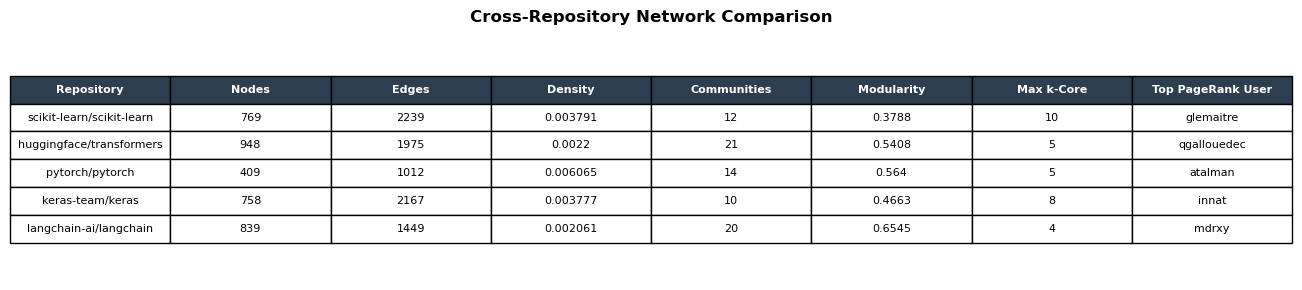

Saved table figure → outputs/figures/network_summary_table.png


In [10]:
summary_df = pd.DataFrame(summary_rows)

# Pretty-print
display_cols = ["repo", "nodes", "edges", "density", "communities",
                "modularity", "max_k_core", "top_pr_node"]
print("\n── Cross-Repo Network Summary ──\n")
print(summary_df[display_cols].to_string(index=False))

# Save
summary_path = f"{TABLES_DIR}/network_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"\n✓ SC7: Cross-repo comparison table saved → {summary_path}")

# ── Visual table using matplotlib ────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 3))
ax.axis("off")

tbl_data  = summary_df[display_cols].values.tolist()
col_labels = ["Repository", "Nodes", "Edges", "Density",
              "Communities", "Modularity", "Max k-Core", "Top PageRank User"]

tbl = ax.table(cellText=tbl_data, colLabels=col_labels,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.2, 1.6)

# Header styling
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor("#2c3e50")
    tbl[0, j].set_text_props(color="white", fontweight="bold")

plt.title("Cross-Repository Network Comparison", fontsize=12,
          fontweight="bold", pad=12)
plt.tight_layout()
tbl_fig_path = f"{FIGURES_DIR}/network_summary_table.png"
plt.savefig(tbl_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved table figure → {tbl_fig_path}")

## Cell 12 — Community Size Distribution

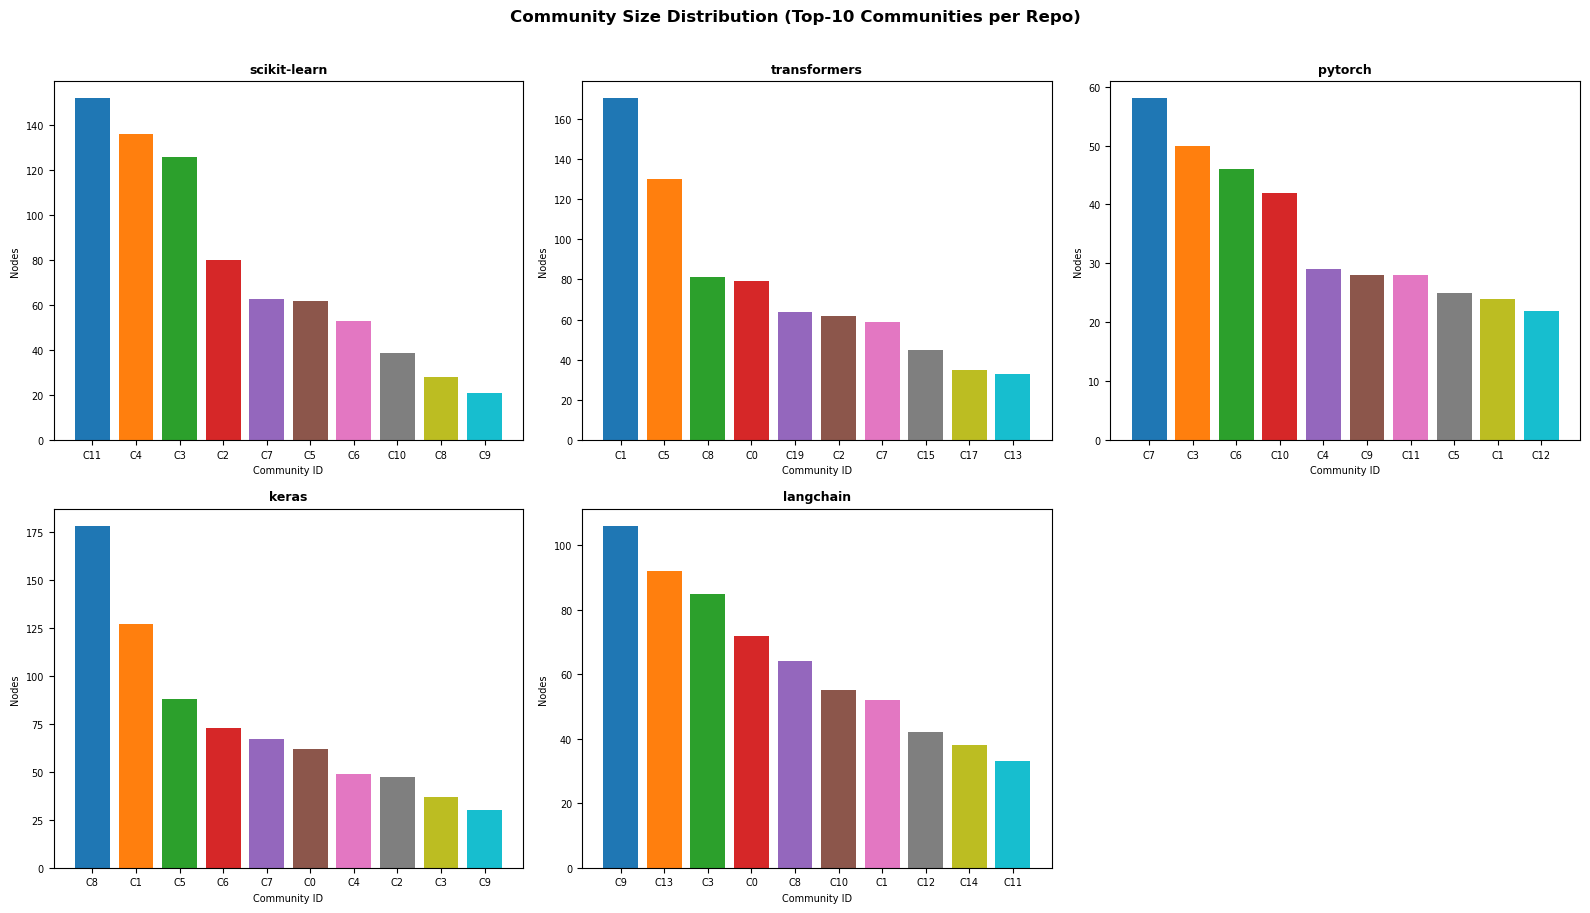

Saved community distribution → outputs/figures/community_size_distribution.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, repo in enumerate(REPOS):
    safe = SAFE_NAMES[repo]
    ax   = axes[i]

    # Re-load centrality CSV (top-20 only saved; community data in GEXF)
    # We stored full centrality in all_centrality dict during the main loop
    cent = all_centrality[repo]
    comm_counts = cent["community"] if "community" in cent.columns else None

    # Fall back: read community from GEXF node attributes
    G_loaded = nx.read_gexf(f"{GEXF_DIR}/{safe}_network.gexf")
    comm_vals = [int(G_loaded.nodes[n].get("community", 0)) for n in G_loaded.nodes()]
    comm_series = pd.Series(comm_vals).value_counts().sort_values(ascending=False)

    top_comms = comm_series.head(10)
    ax.bar(range(len(top_comms)), top_comms.values,
           color=sns.color_palette("tab10", len(top_comms)))
    ax.set_xticks(range(len(top_comms)))
    ax.set_xticklabels([f"C{c}" for c in top_comms.index], fontsize=7)
    ax.set_title(repo.split("/")[1], fontsize=9, fontweight="bold")
    ax.set_xlabel("Community ID", fontsize=7)
    ax.set_ylabel("Nodes", fontsize=7)
    ax.tick_params(labelsize=7)

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle("Community Size Distribution (Top-10 Communities per Repo)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
dist_path = f"{FIGURES_DIR}/community_size_distribution.png"
plt.savefig(dist_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved community distribution → {dist_path}")

## Cell 13 — Save Centrality Tables for Notebook 4

In [12]:
import pickle

# Save the full centrality dict so Notebook 4 can load it without re-running
centrality_pkl_path = f"{PROCESSED_DIR}/all_centrality.pkl"
with open(centrality_pkl_path, "wb") as f:
    pickle.dump(all_centrality, f)
print(f"Saved full centrality dict → {centrality_pkl_path}")

# Also save individual full CSVs (all users, not just top-20)
for repo, cent_df in all_centrality.items():
    safe = SAFE_NAMES[repo]
    full_path = f"{TABLES_DIR}/{safe}_centrality_full.csv"
    cent_df.to_csv(full_path, index=False)
    print(f"  Saved full centrality ({len(cent_df)} users) → {full_path}")

print("\n✅ Centrality data ready for Notebook 4.")

Saved full centrality dict → data/processed/all_centrality.pkl
  Saved full centrality (769 users) → outputs/tables/scikit-learn_scikit-learn_centrality_full.csv
  Saved full centrality (948 users) → outputs/tables/huggingface_transformers_centrality_full.csv
  Saved full centrality (409 users) → outputs/tables/pytorch_pytorch_centrality_full.csv
  Saved full centrality (758 users) → outputs/tables/keras-team_keras_centrality_full.csv
  Saved full centrality (839 users) → outputs/tables/langchain-ai_langchain_centrality_full.csv

✅ Centrality data ready for Notebook 4.


## Cell 14 — Final Output Check

In [13]:
print("=" * 60)
print("NOTEBOOK 3 — FINAL OUTPUT VERIFICATION")
print("=" * 60)

checks = {
    "network_summary.csv":              f"{TABLES_DIR}/network_summary.csv",
    "all_centrality.pkl":               f"{PROCESSED_DIR}/all_centrality.pkl",
}
for repo in REPOS:
    safe = SAFE_NAMES[repo]
    checks[f"{safe}_centrality.csv"]       = f"{TABLES_DIR}/{safe}_centrality.csv"
    checks[f"{safe}_centrality_full.csv"]  = f"{TABLES_DIR}/{safe}_centrality_full.csv"
    checks[f"{safe}_network.gexf"]         = f"{GEXF_DIR}/{safe}_network.gexf"
    checks[f"{safe}_top20_centrality.png"] = f"{FIGURES_DIR}/{safe}_top20_centrality.png"
    checks[f"{safe}_network.html"]         = f"{FIGURES_DIR}/networks/{safe}_network.html"

all_ok = True
for name, path in checks.items():
    exists = os.path.isfile(path)
    status = "✅" if exists else "❌ MISSING"
    print(f"  {status}  {name}")
    if not exists:
        all_ok = False

print()
print("── Success Criteria ──")
for row in summary_rows:
    print(f"  {row['repo']}")
    print(f"    SC1 (nodes≥100, edges≥200): {'✅' if row['sc1_pass'] else '❌'} "
          f"— {row['nodes']} nodes, {row['edges']} edges")
    print(f"    SC3 (modularity>0.3):        {'✅' if row['sc3_pass'] else '❌'} "
          f"— {row['modularity']}")
    print(f"    SC7 (cross-repo table):      ✅")

print()
if all_ok:
    print("All outputs present. Ready for Notebook 4.")
else:
    print("Error  Some outputs missing — check errors above.")

NOTEBOOK 3 — FINAL OUTPUT VERIFICATION
  ✅  network_summary.csv
  ✅  all_centrality.pkl
  ✅  scikit-learn_scikit-learn_centrality.csv
  ✅  scikit-learn_scikit-learn_centrality_full.csv
  ✅  scikit-learn_scikit-learn_network.gexf
  ✅  scikit-learn_scikit-learn_top20_centrality.png
  ✅  scikit-learn_scikit-learn_network.html
  ✅  huggingface_transformers_centrality.csv
  ✅  huggingface_transformers_centrality_full.csv
  ✅  huggingface_transformers_network.gexf
  ✅  huggingface_transformers_top20_centrality.png
  ✅  huggingface_transformers_network.html
  ✅  pytorch_pytorch_centrality.csv
  ✅  pytorch_pytorch_centrality_full.csv
  ✅  pytorch_pytorch_network.gexf
  ✅  pytorch_pytorch_top20_centrality.png
  ✅  pytorch_pytorch_network.html
  ✅  keras-team_keras_centrality.csv
  ✅  keras-team_keras_centrality_full.csv
  ✅  keras-team_keras_network.gexf
  ✅  keras-team_keras_top20_centrality.png
  ✅  keras-team_keras_network.html
  ✅  langchain-ai_langchain_centrality.csv
  ✅  langchain-ai_lan